In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install flowio

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for flowio: filename=flowio-1.4.0-py3-none-any.whl size=21897 sha256=252310000eae33b1cf6dc4af2c3a7e6c60a7031da26887f1261ced04a22ec754
  Stored in directory: /root/.cache/pip/wheels/85/ac/b0/1e3bf1774da784e601a026a80622d0a25979d52ef416c0e027
Successfully built flowio


In [3]:
import shutil
import pandas as pd
import random
import copy
import numpy as np # Import numpy for checking finite values
import matplotlib.pyplot as plt # Import matplotlib for potential debugging
import os
import math

PYTHONHASHSEED = '42'
TF_DETERMINISTIC_OPS = '1'
TF_CUDNN_DETERMINISTIC = '1'
os.environ['PYTHONHASHSEED'] = '42'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'  # For CuDNN ops

import glob
import json
import tensorflow as tf
import sys
import pickle
import time
import csv
import traceback
import gc

from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score

In [4]:

fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

model_path = f'{cellcnn_path}Old_CellCNN/'
if model_path not in sys.path:
    sys.path.append(model_path)

save_path = f'{cellcnn_path}results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [5]:
decache_files = ['timepoints_elaboration', 'model_grid', 'run_models', 'new_datasets_generation',
                'training', 'utils', 'cv_folds', 'classification']

# Remove from cache
from utils import remove_from_cache
remove_from_cache(decache_files)

from model_grid import CellCnn

from timepoints_elaboration import load_data, donation_extraction
from run_models import  trials_train_CellCNN_old, trials_test_CellCNN_old
from new_datasets_generation import splitting_and_dataset_elaboration

from training import run_training, val_res_pred, train_val_finalizing, test_res_pred, find_theta_best
from utils import flatten, remove_labels, retrieve_labels, show_blast_distribution_perc
from utils import prepare_results_to_save, subset_sampling, generate_seeds
from utils import nsub_ncells_comb, save_models, load_models
from cv_folds import generate_LOPOCV_dicts, generate_LOPOCV_folds, extract_fold_features
from classification import find_robust_threshold

timepoints_elaboration not found in cache
model_grid not found in cache
run_models not found in cache
new_datasets_generation not found in cache
training not found in cache
utils removed from cache
cv_folds not found in cache
classification not found in cache


# Training


In [6]:

tuning_exp = 'Trial_5_fix_code_NO_AS_bayesian_tuning'


config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'
os.makedirs(config_save_dir, exist_ok=True)

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)

starting_seed = config['starting_seed']
n_sub = config['n_sub ']
n_cells = config['n_cells']
blast_perc = config['blast_perc']
nfilter = config['nfilter']
maxpool_p = config['maxpool_p']
learning_r = config['learning_r']
labels = config['labels']  # if False internal data augmentation do not takes in account true subset condition

hyper = (nfilter, maxpool_p, learning_r)

print(starting_seed)
print(n_sub)
print(n_cells)
print(blast_perc)
print(nfilter)
print(maxpool_p)
print(learning_r)
print(labels)


1000
3
100000
[0.0001, 0.001, 0.01]
[5, 7, 9]
[0.01, 1, 10, 100]
[0.001, 0.005]
False


In [7]:
%%time

data_folder = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)


Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
Elaborating file 8: /content/drive/MyDrive/0.

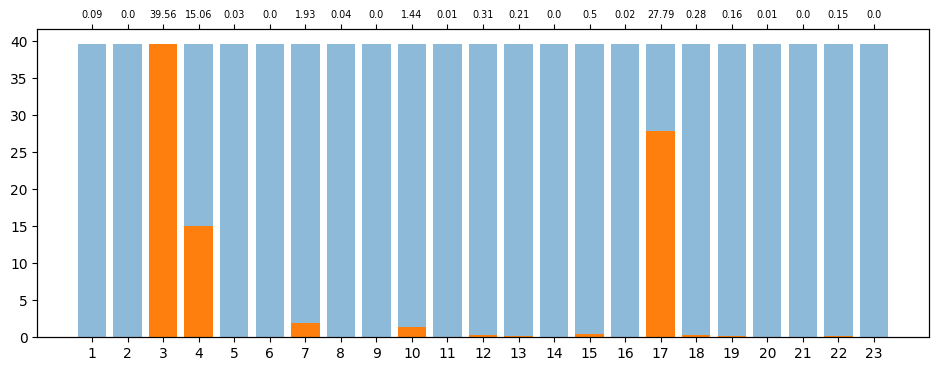

[np.float64(0.09), np.float64(0.0), np.float64(39.56), np.float64(15.06), np.float64(0.03), np.float64(0.0), np.float64(1.93), np.float64(0.04), np.float64(0.0), np.float64(1.44), np.float64(0.01), np.float64(0.31), np.float64(0.21), np.float64(0.0), np.float64(0.5), np.float64(0.02), np.float64(27.79), np.float64(0.28), np.float64(0.16), np.float64(0.01), np.float64(0.0), np.float64(0.15), np.float64(0.0)]


In [8]:

tot_perc_list = show_blast_distribution_perc(ALL_DATASETS, multiple_donations, return_perc = True)
print(tot_perc_list)

In [9]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

In [10]:
%%time

start_lopocv_fold = 0
end_lopocv_fold = 0

exp = 'Trial_5_fix_code_AS_Ensemble'

save_memory = False # set True to save RAM memory
grid = True

weights_outdir = f'{config_save_dir}/weights'
os.makedirs(weights_outdir, exist_ok=True)
full_process_time_list = []

for LOPOCV_fold_idx, (train_kfolds, test_pat) in enumerate(LOPOCV_patients_folds): # for each LOPO fold
  if LOPOCV_fold_idx >= start_lopocv_fold:

    LOPOCV_start = time.time()

    # === Import Base seed === #
    seed_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/'

    with open(os.path.join(seed_load_dir, 'tuning_seed_info.pkl'), 'rb') as f:
                            seed_info = pickle.load(f)

    print('check seeds:', seed_info)
    training_split_seed = seed_info['final_tuning_base_seed']
    fold_base_seed = seed_info['fold_base_seed']

    # === Import Tuned theta* === #

    tuning_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPOCV_fold_idx}/tuning/results'

    with open(os.path.join(tuning_load_dir, 'best_ncells.pkl'), 'rb') as f:
                        best_ncells = pickle.load(f)

    with open(os.path.join(tuning_load_dir, 'best_nsub.pkl'), 'rb') as f:
                        best_nsub = pickle.load(f)

    print(f'Theta*: {best_ncells, best_nsub}')


    base_seed = fold_base_seed

    if save_memory:
        if LOPOCV_fold_idx != start_lopocv_fold:
            multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)


    # === Generate AS per each fold === #

    # retrieve train and val patients per fold
    fold_features = extract_fold_features(train_kfolds, multiple_donations, tot_perc_list) #Fold feature dictionary creation
    print(f'Start Artificial Sample generation')
    AS_generating_start = time.time()

    base_final_training_AS_seed = base_seed

    # generate the Artificial Samples
    artificial_samples_folds = []
    for fold, (train_features, val_features) in fold_features.items():

        final_training_AS_seed = base_seed + fold
        train_donors_idx, val_donors_idx = train_features[0], val_features[0] # retrieve patients form fold features dictionary

        # extraxt samples using pre-slitted indexes
        train_datasets_extracted = donation_extraction(train_donors_idx, multiple_donations, ALL_DATASETS)
        val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
        test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)

        # generate Artificial Samples
        (new_train_datasets, new_train_y,
         new_val_datasets,   new_val_y, _, _ ) = splitting_and_dataset_elaboration(train_datasets_extracted,
                                                                            val_datasets_extracted,
                                                                            test_datasets_extracted,
                                                                            n_sub, n_cells,           # number of AS, number of cells per AS
                                                                            final_training_AS_seed, # seed for random extraction
                                                                            blast_perc = blast_perc,  # % of blast cells extracted
                                                                            per_perc = True)          # one Unhealthy AS per %

        # store generated AS
        artificial_samples_folds.append([new_train_datasets, new_train_y, new_val_datasets, new_val_y])#, new_test_datasets, new_test_y])

    if save_memory:
        # delete for RAM saving
        del ALL_DATASETS
        del test_datasets_extracted
        del train_datasets_extracted
        del new_train_datasets
        del new_val_datasets
        gc.collect()

    print(f'Time elapsed for AS generation: {AS_generating_start - time.time()}')
    print(f'End of Artificial Sample generation')

    # fix seed for comparisons
    base_seed = training_split_seed
    for i in range(1):


            # prepare storing variables
            best_thresholds = []       # save thresholds
            roc_metrics = []
            val_predicted_for_roc = [] # store predictions from tuning for threshold tuning

            print(f'Model {i+1}. Testing params -> ncells: {best_ncells}, nsubs: {best_nsub}')
            print(f'5 Fold CV started')

            val_predicted_for_roc_folds = []
            f1_across_folds = []

            for fold_idx, (train_features, val_features) in fold_features.items():
                print(f'\nCV Fold {fold_idx} starts (LOPOCV iteration: {LOPOCV_fold_idx})\n')
                fold_start = time.time()

                # Load data from stored fold-specific AS
                print('Loading data...')
                (new_train_datasets, new_train_y,
                 new_val_datasets, new_val_y) = artificial_samples_folds[fold_idx] # retrieve generated AS from pre-generated AS
                print('Data Loaded...')

                # remove labels (random search without labels is required)
                train, val = train_val_finalizing(new_train_datasets, new_val_datasets, grid, labels)

                tuning_predictions = []
                tuning_results = []

                trials = 1 ### 3  number of time the model have to be trained (at each time a different seed is used)

                # === Generate seed lists in advance === #

                train_CV_seed = base_seed + i*1000 + fold_idx*10 + 1
                seed_list = generate_seeds(len(LOPOCV_patients_folds)*2, seed = train_CV_seed)

                pred_CV_seed = base_seed + i*1000 + fold_idx*10 + len(fold_features)*10
                tuning_prediction_seed_list = generate_seeds(trials, seed = pred_CV_seed)

                base_seed += 200
                final_orig_pred_seed = base_seed
                original_prediction_seed_list = generate_seeds(trials, seed = final_orig_pred_seed)

                base_seed += 1000
                final_rob_pred_seed = base_seed
                robust_prediction_seed_list = generate_seeds(3, seed = final_rob_pred_seed)

                try:
                        # === Train Models === #

                        models_lists = run_training(CellCnn,
                                            train, new_train_y,
                                            new_val_datasets = val, new_val_y = new_val_y,
                                            seed_list =  seed_list, hyper = hyper, grid = grid, labels = labels,
                                            trials = trials,
                                            cells_per_sub = best_ncells, ## Tuned ncells ##
                                            best_nsub = best_nsub,        ## Tuned nsub   ##
                                            max_epochs = 1,              ### 100,
                                            nrun = None,                  #grid search, so doesn't matter wht number
                                            generate = False,
                                            outdir = weights_outdir)



                        # === Save Models === #
                        for trial_i, model in enumerate(models_lists):
                            save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/inner_fold_{fold_idx}/models/seed_{trial_i}'
                            os.makedirs(save_dir, exist_ok=True)
                            save_models(model, save_dir)

                        # === Prediction Approach: CellCNN with tau = 0.5 === #

                        if save_memory:
                            print('Load data for Test set')
                            multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

                        test_datasets_extracted = donation_extraction(test_pat, multiple_donations, ALL_DATASETS)

                        original_test_datasets, original_test_y = retrieve_labels(test_datasets_extracted, remove = True, flat = True)
                        print(f'Ground thruth labels: {original_test_y}')

                        # Test set prediction
                        original_predictions_list, original_results_list = trials_test_CellCNN_old(models_lists, original_test_datasets, original_prediction_seed_list)

                        print('Save CellCNN Prediction results')
                        save_original_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/results/inner_fold_{fold_idx}/predictions/direct'
                        os.makedirs(save_original_dir, exist_ok=True)

                        with open(os.path.join(save_original_dir, 'original_predictions_list.pkl'), 'wb') as f:
                                        pickle.dump(original_predictions_list, f)
                        with open(os.path.join(save_original_dir, 'original_results_list.pkl'), 'wb') as f:
                                        pickle.dump(original_results_list, f)
                        with open(os.path.join(save_original_dir, 'original_test_y.pkl'), 'wb') as f:
                                        pickle.dump(original_test_y, f)

                        # === Prediction Approach: Resamplimg === #

                        print('Start Robust prediction using ROC threshold')

                        test_resample_n = 100000 #same dimension of AS
                        k = 2 ### 100

                        per_donor_original_test_datasets, per_donor_original_test_y = retrieve_labels(test_datasets_extracted, remove = False)
                        print(f'Ground thruth labels per patient: {per_donor_original_test_y}')

                        (_, #test_total_labels,               # Predicted resampled subsets labels
                            test_total_pred_lists,           # Mean predictions of resampled subsets across trials (per patient)
                            test_total_trial_pred_lists,     # Lists of trial predictions of resampled subsets (per patient)
                            per_donor_resampled_test_y       # True labels of resampled subsets (per patient)
                                                    ) = test_res_pred(
                                                        models_lists,
                                                        per_donor_original_test_datasets,
                                                        test_resample_n,
                                                        k,
                                                        0.5,
                                                        trials,
                                                        seed = robust_prediction_seed_list[1])



                        save_robust_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/results/inner_fold_{fold_idx}/predictions/robust'
                        os.makedirs(save_robust_dir, exist_ok=True)

                        with open(os.path.join(save_robust_dir, 'test_total_trial_pred_lists.pkl'), 'wb') as f:
                                        pickle.dump(test_total_trial_pred_lists, f)
                        with open(os.path.join(save_robust_dir, 'per_donor_resampled_test_y.pkl'), 'wb') as f:
                                        pickle.dump(per_donor_resampled_test_y, f)
                        with open(os.path.join(save_robust_dir, 'per_donor_original_test_y.pkl'), 'wb') as f:
                                        pickle.dump(per_donor_original_test_y, f)


                except Exception as e:
                        print(f"Training error: {e}")
                        traceback.print_exc()

                fold_end = time.time()
                print('')
                print(f'End CV Fold {fold_idx}. Time Elapsed: {fold_start - fold_end}')
                print(f'Time elapsed from start LOPOCV iteration: {LOPOCV_start - fold_end}')
                print('')

            if save_memory:

                del artificial_samples_folds
                del new_train_datasets
                del train
                del new_val_datasets
                del val
                gc.collect()


                multiple_donations, ALL_DATASETS = load_data(data_path = data_folder, ext = extension)

            try:

                        # === Threshold tuning: \tau^*_{ROC} and \tau^*_{RES} === #

                        print('Start Threshold tuning after the training')

                        ensemble_mean_probs_per_patient = []
                        ensamble_val_y = []
                        ensamble_roc_samples_predictions = []

                        tuning_models_dir = f'{cellcnn_path}experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/training/'
                        os.makedirs(tuning_models_dir, exist_ok=True)

                        fold_features = extract_fold_features(train_kfolds, multiple_donations, tot_perc_list) #Fold feature dictionary creation

                        for fold_idx, (train_features, val_features) in fold_features.items():

                            # === Rebuild models per CV fold === #

                            model_trials_dir = f'{tuning_models_dir}/inner_fold_{fold_idx}/models/'
                            all_trials = os.listdir(model_trials_dir)

                            loaded_models_lists = []
                            for i, trial in enumerate(all_trials):
                                model_dir = f'{model_trials_dir}/seed_{i}'
                                with open(os.path.join(model_dir, 'metadata.pkl'), 'rb') as f:
                                    meta = pickle.load(f)

                                model = load_models(CellCnn, meta)
                                loaded_models_lists.append(model)

                            print(f'Iteration {fold_idx}: Models Loaded!')

                            thr_tuning_seed = base_seed + fold_idx*10
                            tuning_prediction_seed_list = generate_seeds(len(all_trials), seed = thr_tuning_seed)


                            # extraxt samples using pre-slitted indexes
                            val_donors_idx = val_features[0] # retrieve patients form fold features dictionary
                            val_datasets_extracted = donation_extraction(val_donors_idx, multiple_donations, ALL_DATASETS)
                            per_donor_original_val_datasets, per_donor_original_val_y = retrieve_labels(val_datasets_extracted, remove = False)

                            # === RES === #
                            val_resample_n = 100000 #same dimension of the AS
                            k = 2 ### 50

                            (_, # predictions divided by patient -> file -> sampled subsets pred
                             total_trial_pred_lists,
                             mean_probs_per_patient) = val_res_pred(loaded_models_lists, per_donor_original_val_datasets, val_resample_n, k, tuning_prediction_seed_list[0])

                            # RES
                            ensemble_mean_probs_per_patient += mean_probs_per_patient # means across weights initializations
                            ensamble_val_y += per_donor_original_val_y

                            # ROC
                            for patient in total_trial_pred_lists:
                              sample_mean_across_subsets_seeds = []
                              for sample in patient:
                                  mean_across_seeds = []
                                  for subset in sample[0]: # assume consistency in the number of subsets
                                      mean_across_seeds.append(np.mean(subset))
                                  sample_mean_across_subsets_seeds.append(np.mean(mean_across_seeds))
                              # store sample mean predictions across seeds and subsets
                              ensamble_roc_samples_predictions += sample_mean_across_subsets_seeds


                        base_seed += len(fold_features)*100

                        # Compute and Save RES
                        tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/tuning/resampling/'
                        os.makedirs(tuning_save_dir, exist_ok=True)

                        ensemble_robust_threshold, tot_per_tr_f1_scores = find_robust_threshold(ensemble_mean_probs_per_patient, 'f1', closest = True)
                        ensemble_robust_threshold = ensemble_robust_threshold/100

                        with open(os.path.join(tuning_save_dir, 'ensemble_mean_probs_per_patient.pkl'), 'wb') as f:
                                pickle.dump(ensemble_mean_probs_per_patient, f) # prediction used to tune the threshold

                        with open(os.path.join(tuning_save_dir, 'ensemble_robust_threshold.pkl'), 'wb') as f:
                                pickle.dump(ensemble_robust_threshold, f) # prediction used to tune the threshold

                        with open(os.path.join(tuning_save_dir, 'tot_per_tr_f1_scores.pkl'), 'wb') as f:
                                pickle.dump(tot_per_tr_f1_scores, f) # prediction used to tune the threshold

                        with open(os.path.join(tuning_save_dir, 'total_trial_pred_lists.pkl'), 'wb') as f:
                                pickle.dump(total_trial_pred_lists, f) # prediction used to tune the threshold

                        # Compute and Save ROC
                        tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/tuning/roc/'
                        os.makedirs(tuning_save_dir, exist_ok=True)

                        #### comupute roc curve on resampled to fine the best threshold
                        fpr, tpr, thresholds = metrics.roc_curve(flatten(ensamble_val_y), ensamble_roc_samples_predictions, pos_label=1)# compute ROC curve
                        show_thresholds = (fpr, tpr, thresholds)
                        optimal_idx = np.argmax(tpr >= 0.95)  # index of the threshold that has the highest tpr
                        ensemble_roc_threshold = thresholds[optimal_idx]    # extract the threshold

                        print(f"Best Threshold for MRD (Recall=100%): {ensemble_roc_threshold}")
                        with open(os.path.join(tuning_save_dir, 'ensamble_val_y.pkl'), 'wb') as f:
                                pickle.dump(ensamble_val_y, f) # prediction used to tune the threshold
                        with open(os.path.join(tuning_save_dir, 'ensemble_roc_threshold.pkl'), 'wb') as f:
                                pickle.dump(ensemble_roc_threshold, f) # prediction used to tune the threshold
                        with open(os.path.join(tuning_save_dir, 'ensamble_roc_samples_predictions.pkl'), 'wb') as f:
                                pickle.dump(ensamble_roc_samples_predictions, f) # prediction used to tune the threshold
                        with open(os.path.join(tuning_save_dir, 'show_thresholds.pkl'), 'wb') as f:
                                pickle.dump(show_thresholds, f) # prediction used to tune the threshold




            except Exception as e:
                        print(f'Post-training threshold tuning error!')
                        print(f"Training error: {e}")
                        traceback.print_exc()



            #save seeds outside the ensemble
            tuning_save_dir = f'{cellcnn_path}/experiments/experiment_{exp}/outer_fold_{LOPOCV_fold_idx}/ensemble/'
            os.makedirs(tuning_save_dir, exist_ok=True)


            with open(os.path.join(tuning_save_dir, 'seed_info.pkl'), 'wb') as f:
                                pickle.dump({
                                    'starting_seed': starting_seed,
                                    'LOPOCV_fold_idx': LOPOCV_fold_idx,
                                    'fold_base_seed': fold_base_seed,
                                    'base_final_training_AS_seed': base_final_training_AS_seed,
                                    'training_split_seed': training_split_seed,
                                    'final_base_seed': base_seed
                                }, f)

            elapsed_time_for_LOPOCV = time.time() - LOPOCV_start
            print(f'elapsed_time_for_LOPOCV fold {LOPOCV_fold_idx}: {elapsed_time_for_LOPOCV}')

            with open(os.path.join(tuning_save_dir, 'elapsed_time_for_LOPOCV.pkl'), 'wb') as f:
                                pickle.dump(elapsed_time_for_LOPOCV, f)

    full_process_time_list.append(elapsed_time_for_LOPOCV)
    if LOPOCV_fold_idx >= end_lopocv_fold:
        break



check seeds: {'starting_seed': 1000, 'LOPOCV_fold_idx': 0, 'fold_base_seed': 1000, 'final_tuning_base_seed': 12510}
Theta*: (100, 450)
Start Artificial Sample generation
New training datasets creation...
7
2
Tot blast data in the donor timepoints: 9147
Tot blast data in the donor timepoints: 9374
Extraction Done
Condition: 1
Tot blast data in the donor timepoints: 44697
Tot blast data in the donor timepoints: 46110
Extraction Done
Condition: 1
Tot blast data in the donor timepoints: 518
Tot blast data in the donor timepoints: 916
Tot blast data in the donor timepoints: 916
Extraction Done
Condition: 1
Tot blast data in the donor timepoints: 72
Tot blast data in the donor timepoints: 72
Extraction Done
Condition: 1
Tot blast data in the donor timepoints: 2390
Tot blast data in the donor timepoints: 2467
Extraction Done
Condition: 1
Tot blast data in the donor timepoints: 639
Tot blast data in the donor timepoints: 654
Extraction Done
Condition: 1
Tot blast data in the donor timepoints: 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Sta

Ground thruth labels: [1, 0]
Weight Initialization 1 out of 1 started!
seed: 747712. Type: <class 'numpy.int64'>
seed: 747712. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step
Done
Trial 1 Done!

Save CellCNN Prediction results
Start Robust prediction using ROC threshold
Ground thruth labels per patient: [[1, 0]]
2
Weight Initialization 1 out of 1 started!
seed: 102429. Type: <class 'numpy.int64'>
seed: 102429. Type: <class 'int'>


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Done
Trial 1 Done!

Weight Initialization 1 out of 1 started!
seed: 342264. Type: <class 'numpy.int64'>
seed: 342264. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Done
Trial 1 Done!

Weight Initialization 1 out of 1 started!
seed: 380104. Type: <class 'numpy.int64'>
seed: 380104. Type: <class 'int'>


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Done
Trial 1 Done!

Chosen threshold: 50. Associated F1_score: 0.8947
Best Threshold for MRD (Recall=100%): 0.5035246908664703
elapsed_time_for_LOPOCV fold 0: 828.176531791687
CPU times: user 14min 12s, sys: 1min 35s, total: 15min 47s
Wall time: 13min 48s
